In [1]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
import os
#현재 폴더 경로; 작업 폴더 기준
print(os.getcwd())

C:\Users\SSAFY\Desktop\sini_jini\PJT\02_pjt\bank\skeleton


In [9]:
df = pd.read_csv("../data/NFLX.csv")

In [13]:
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900
...,...,...,...,...,...,...,...
1004,2022-01-31,401.970001,427.700012,398.200012,427.140015,427.140015,20047500
1005,2022-02-01,432.959991,458.480011,425.540009,457.130005,457.130005,22542300
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011,429.480011,14346000
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006,405.600006,9905200


# A. 데이터 천저리 - 데이터 읽어오기

In [21]:
df[['Date','Open','High','Low','Close']]

,Date,Open,High,Low,Close
0,2018-02-05,262.000000,267.899994,250.029999,254.259995
1,2018-02-06,247.699997,266.700012,245.000000,265.720001
2,2018-02-07,266.579987,272.450012,264.329987,264.559998
3,2018-02-08,267.079987,267.619995,250.000000,250.100006
4,2018-02-09,253.850006,255.800003,236.110001,249.470001
...,...,...,...,...,...
1004,2022-01-31,401.970001,427.700012,398.200012,427.140015
1005,2022-02-01,432.959991,458.480011,425.540009,457.130005
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006


# B.데이터 전처리 - 2021년 이후의 종가 데이터 출력

In [36]:
df['Date'] = pd.to_datetime(df['Date'])

In [57]:
df_2021 = df.loc[df['Date'].dt.year >= 2021]

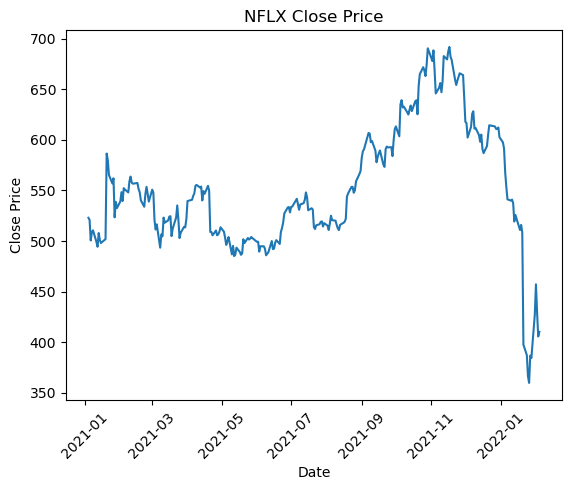

In [58]:
x = df_2021['Date']  # x 좌표값
y = df_2021['Close']  # y 좌표값

plt.plot(x, y)
plt.xticks(rotation = 45)

plt.title('NFLX Close Price')
plt.xlabel('Date')
plt.ylabel('Close Price')

# 그래프 표시
plt.show()

# C.데이터 분석 - 2021년 이후 최고, 최저 종가 출력하기

In [59]:
max_price = df_2021['Close'].max()
min_price = df_2021['Close'].min()

In [60]:
print('최고 종가:',max_price)
print('최저 종가:',min_price)

최고 종가: 691.690002
최저 종가: 359.700012


# D.데이터 분석 - 2021년 이후 월별 평균 종가 출력

In [61]:
df_2021_d = df_2021
df_2021_d['Month'] = df_2021_d['Date'].dt.strftime('%y-%m')

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_10812\2950729875.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2021_d['Month'] = df_2021_d['Date'].dt.strftime('%y-%m')


In [70]:
ave_df_2021 = df_2021_d.groupby("Month").mean()

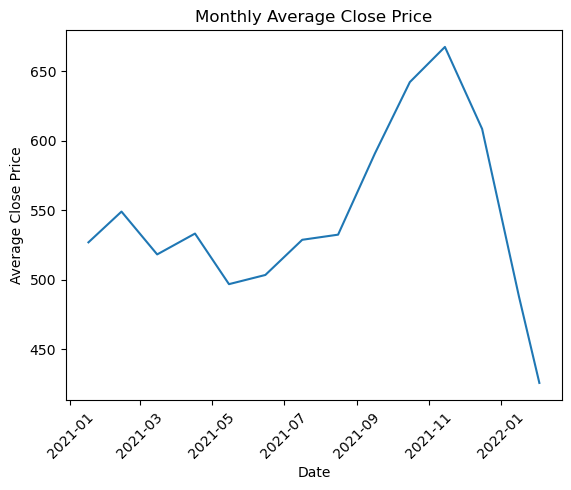

In [72]:
x = ave_df_2021['Date']  # x 좌표값
y = ave_df_2021['Close']  # y 좌표값

plt.plot(x, y)
plt.xticks(rotation = 45)

plt.title('Monthly Average Close Price')
plt.xlabel('Date')
plt.ylabel('Average Close Price')

# 그래프 표시
plt.show()

# E. 데이터 시각화 - 2022년 이후 최고, 최저, 종가 시각화

In [74]:
df_2022 = pd.read_csv("../data/NFLX.csv")

In [75]:
df_2022['Date'] = pd.to_datetime(df_2022['Date'])

In [76]:
df_2022 = df_2022.loc[df_2022['Date'].dt.year >= 2022]

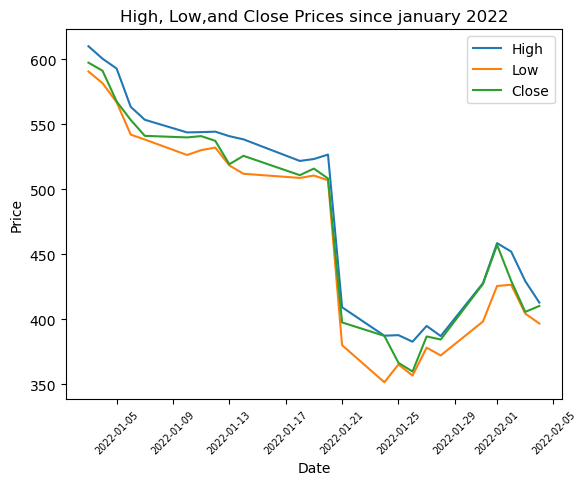

In [82]:
x = df_2022['Date']  # x 좌표값
y = df_2022['High']  # y 좌표값
y2 = df_2022['Low'] # y2 좌표값
y3 = df_2022['Close'] # y2 좌표값

# 그래프 그리기
plt.plot(x, y, label='High')
plt.plot(x, y2, label='Low')
plt.plot(x, y3, label='Close')
# 범례 추가
plt.legend()
plt.xticks(size = 7,rotation = 45)
# 그래프에 제목과 축 레이블 추가
plt.title('High, Low,and Close Prices since january 2022')
plt.xlabel('Date')
plt.ylabel('Price')

# 그래프 표시
plt.show()